### Read in Data + QC

In [67]:
from __future__ import annotations
import anndata as ad 
import scanpy as sc 

sc.settings.set_figure_params(dpi=50, facecolor="white")

In [104]:
# start with heart and aorta
data_path = "./droplet/Heart_and_Aorta-10X_P7_4" 

# Load the data
adata = sc.read_10x_mtx(data_path, var_names='gene_symbols', cache=True)

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("Mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [115]:
# filter cells based on QC metrics 
adata = adata[
    (adata.obs['n_genes_by_counts'] > 200) &
    (adata.obs['pct_counts_mt'] < 10)
]

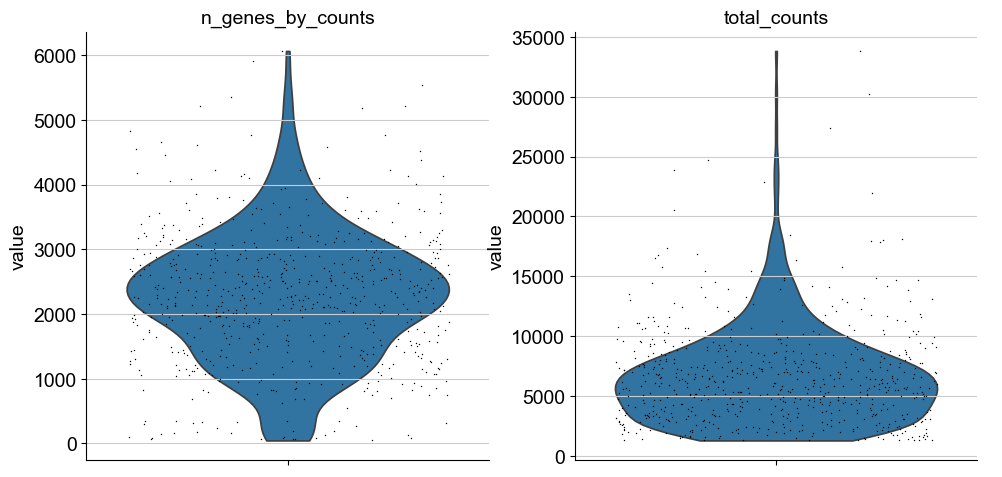

In [105]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

### Normalization

In [106]:
# save raw counts 
adata.layers['counts'] = adata.X.copy() 

# normalize by sequencing depth such that cells have same count 
sc.pp.normalize_total(adata) 

# log transform data
sc.pp.log1p(adata) 

### Feature Selection

In [107]:
print(f'Total Cells: {adata.n_obs}')
print(f'Total Genes: {adata.n_vars}') # genes 
print(f'Total Genes: {adata.shape}') # (n_cells, n_genes)

Total Cells: 654
Total Genes: 23433
Total Genes: (654, 23433)


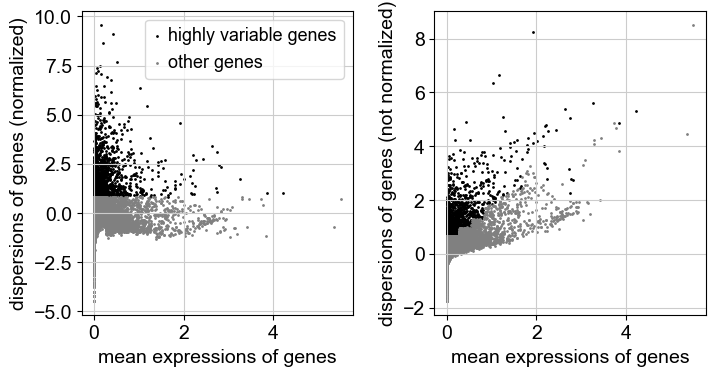

In [108]:
# annotate highly variable genes (2000 for tissue-specific analysis)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

/opt/homebrew/Caskroom/miniconda/base/envs/bioinfo/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


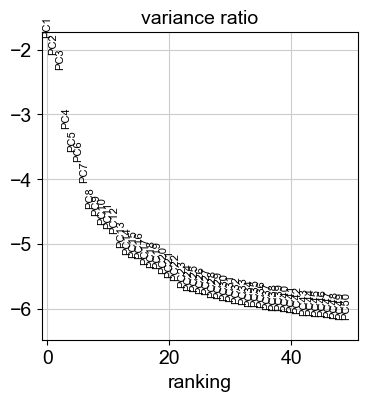

In [109]:
sc.tl.pca(adata, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

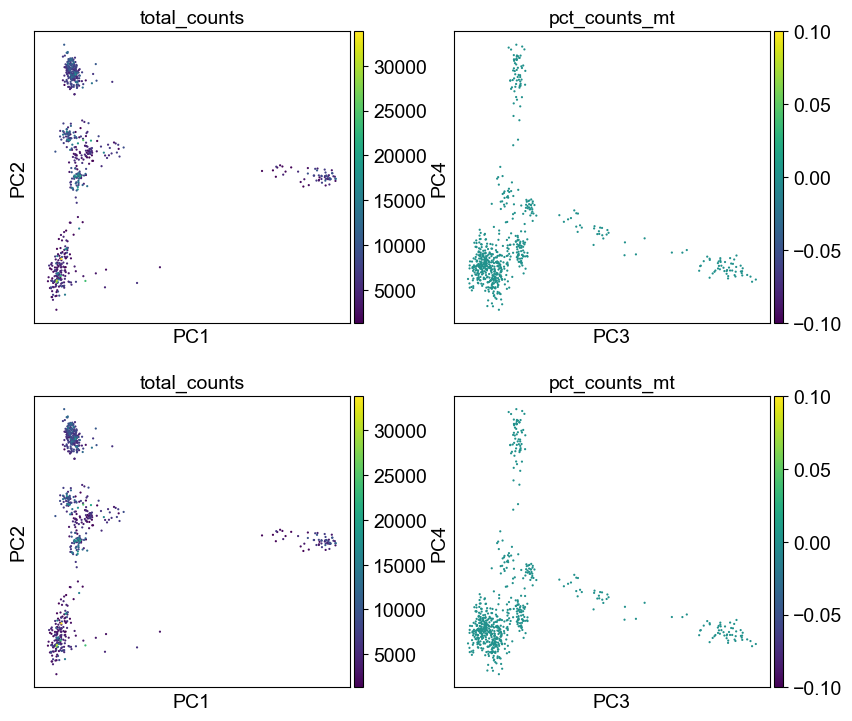

In [110]:
# subset data to keep only highly variable genes 

sc.pl.pca(
    adata,
    color=["total_counts", "pct_counts_mt", "total_counts", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=10,
)

### Export Preprocessed Data (QC + Normalization + PCA) 

In [111]:
adata_preprocess = adata.copy()
adata_preprocess.write_h5ad('heart_aorta_qc_normalized_pca.h5ad')

import pandas as pd

expr_df = pd.DataFrame(
    adata_preprocess.X.toarray() if hasattr(adata_preprocess.X, 'toarray') else adata_preprocess.X,
    index=adata_preprocess.obs_names,
    columns=adata_preprocess.var_names
)
expr_df.to_csv('heart_aorta_qc_normalized_pca.csv')

### Clustering

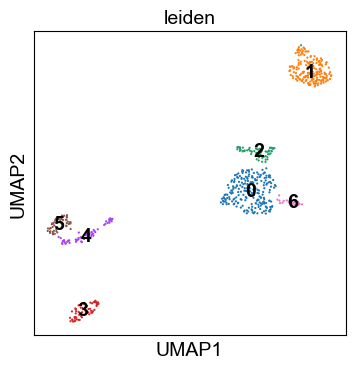

In [112]:
sc.pp.neighbors(adata) # compute neighborhood graph 
sc.tl.leiden(adata, resolution = 0.5) # run leiden clustering 

# plot UMAP 
sc.tl.umap(adata) 

# visualize clusters
sc.pl.umap(adata, color='leiden', size=10, legend_loc='on data')


sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
sc.tl.leiden(adata, resolution=0.5)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=['leiden', 'pct_counts_mt'],
    ncols=2,
    size=3,
)

### Export Data (UMAP embeddings & Cluster Assignments)

In [113]:
# after clustering + UMAP, export labeled data
adata.write_h5ad('heart_aorta_clustered_labeled.h5ad')

# export cluster assignments
metadata_df = adata.obs[['leiden']].copy()
metadata_df.to_csv('cell_clusters.csv')

# export PCA & UMAP coordinates
import pandas as pd
pca_df = pd.DataFrame(
    adata.obsm['X_pca'][:, :50],  # First 50 PCs
    columns=[f'PC_{i+1}' for i in range(50)],
    index=adata.obs_names
)
umap_df = pd.DataFrame(
    adata.obsm['X_umap'],
    columns=['UMAP_1', 'UMAP_2'],
    index=adata.obs_names
)
pca_df.to_csv('pca_coordinates.csv')
umap_df.to_csv('umap_coordinates.csv')

print("Export complete!")

Export complete!


### Training Split 
Split data into 70% training, 30% testing

In [119]:
print(adata.obs['cell_type'].values)

KeyError: 'cell_type'